## 1. Import Libraries and Setup

In [32]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Import KMRF and strategy classes
from kmrf import KMRF
from KMRF_training_config import KMRF_Training_Config
from regime_trading_strategy_contrarian import RegimeTradingStrategy, StrategyParameters

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported successfully")
print(f"Notebook initialized: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✓ Libraries imported successfully
Notebook initialized: 2025-11-19 22:17:40


## 3. Load Model and Generate Predictions

In [33]:
test_or_val_set = 'test'
model = KMRF.load_model('saved_models/KMRF_new/original/us_equity/SPDR S&P 500 ETF_KMRF_model.pkl')

KMRF model initialized
  Asset: SPDR S&P 500 ETF
  Asset class: us_equity
  Classification type: original
  Training end date: 20181231
  Test end date: All available data
  Data type: master
  Data path: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/data/master_df.csv
  KAMA+MSR model directory: /Users/jessegoodman/Desktop/Stevens MFE/Sem3/FE800/FE800_project_code/saved_models/KAMA_MSR/us_equity/20181231
  Validation/Test split: Will be calculated after loading data
  Random seed: 1010
  Feature window size: 1 days
  Feature asset classes: []
  Feature selection: Boruta=True, Consensus=False
  Custom XGB parameters: {'n_estimators': 220, 'max_depth': 13, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.25, 'min_child_weight': 95, 'gamma': 0.045, 'random_state': 1010, 'n_jobs': -1, 'tree_method': 'hist', 'enable_categorical': False}


In [34]:
print("\nGenerating validation predictions...")
predictions = model.predict(test_or_val=test_or_val_set)

print(f"\n✓ Predictions generated")
print(f"Shape: {predictions.shape}")
print(f"Period: {predictions.index[0].date()} to {predictions.index[-1].date()}")
print(f"\nColumns: {list(predictions.columns)}")
print(f"\nFirst 5 predictions:")
print(predictions.head())


Generating validation predictions...

Generating predictions...
  Input shape: (957, 109)
  Using pre-selected features: 109
✓ Generated probability predictions: (957, 4)
  Using test set: 2022-01-03 00:00:00 to 2025-10-24 00:00:00

✓ Predictions generated
Shape: (957, 4)
Period: 2022-01-03 to 2025-10-24

Columns: ['P(LV_Bull)', 'P(LV_Bear)', 'P(HV_Bull)', 'P(HV_Bear)']

First 5 predictions:
            P(LV_Bull)  P(LV_Bear)  P(HV_Bull)  P(HV_Bear)
date                                                      
2022-01-03    0.995841    0.002900    0.000799    0.000460
2022-01-04    0.995413    0.003332    0.000799    0.000456
2022-01-05    0.995262    0.003226    0.000952    0.000560
2022-01-06    0.997003    0.001118    0.001171    0.000707
2022-01-07    0.997546    0.000964    0.000986    0.000504


In [35]:
# Visualize predictions
print("\n" + "="*80)
print("VISUALIZING PREDICTIONS")
print("="*80)
model.viz_predictions(test_or_val=test_or_val_set)


VISUALIZING PREDICTIONS


ValueError: No test predictions available. Generate predictions first.

## 4. Analyze Prediction Probabilities

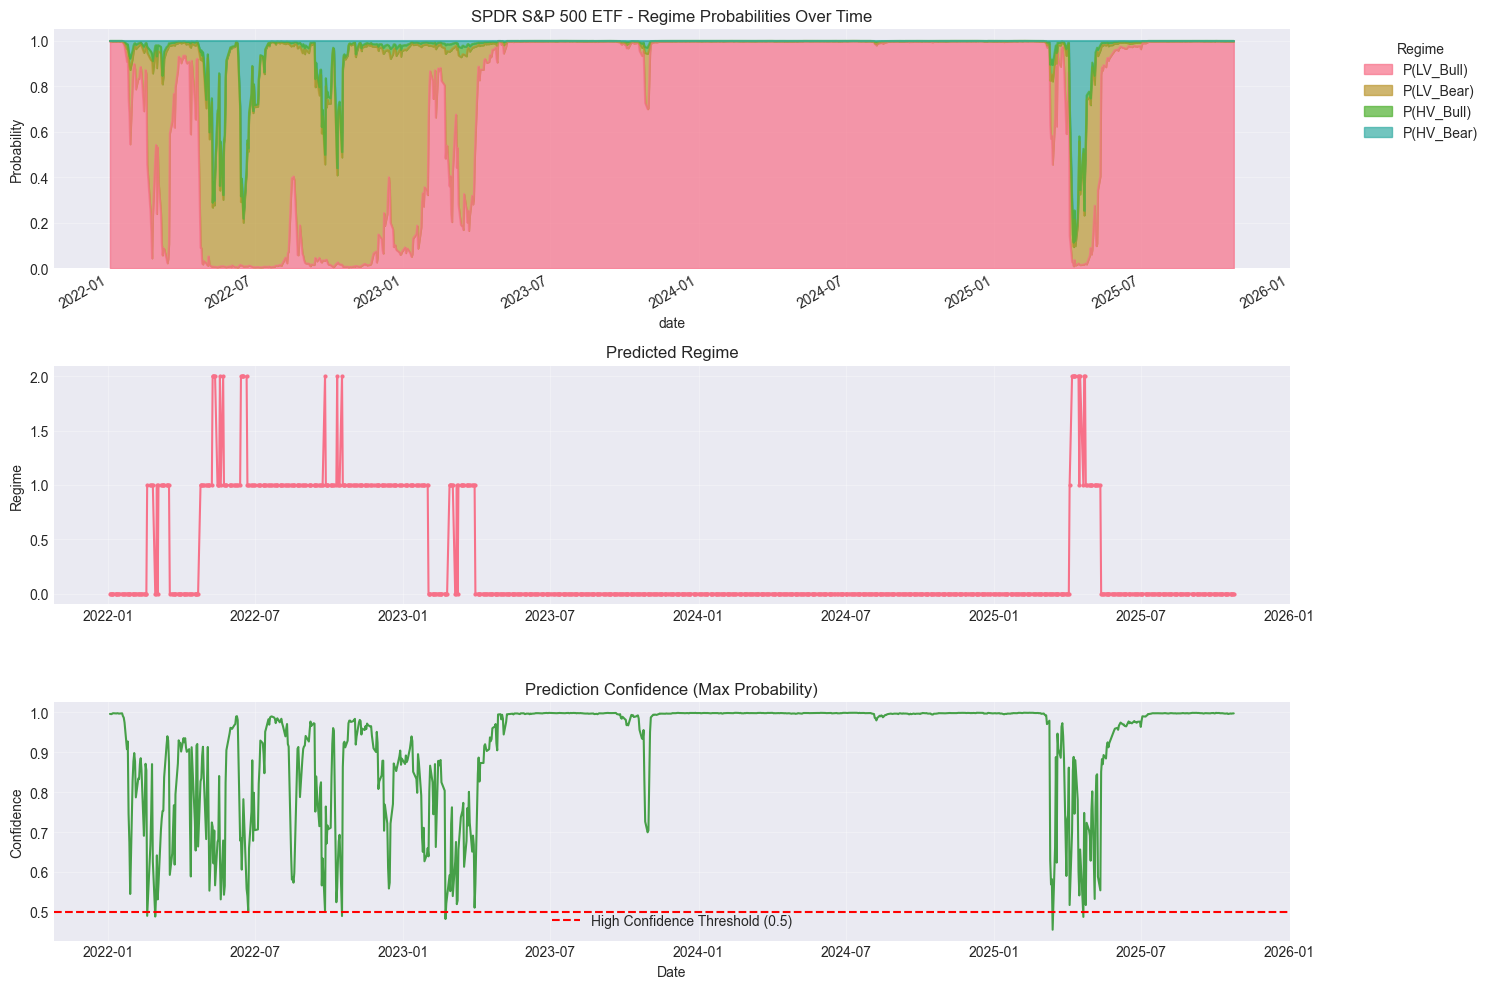


📊 Probability Statistics:
       P(LV_Bull)  P(LV_Bear)  P(HV_Bull)  P(HV_Bear)
count  957.000000  957.000000  957.000000  957.000000
mean     0.726961    0.226625    0.007889    0.038525
std      0.400866    0.348311    0.011179    0.122251
min      0.002343    0.000282    0.000488    0.000282
25%      0.340211    0.000830    0.000882    0.000503
50%      0.995379    0.002340    0.001640    0.000914
75%      0.997735    0.423668    0.010971    0.011240
max      0.998831    0.990268    0.076093    0.888197


In [ ]:
# Extract regime probabilities and predicted regime
regime_probs = predictions.copy()
predicted_regime = predictions.apply(lambda row: row.argmax(), axis=1).rename('Predicted Regime')

# Visualize regime probabilities over time
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# Plot 1: Regime probabilities stacked
regime_probs.plot(kind='area', stacked=True, ax=axes[0], alpha=0.7)
axes[0].set_title(f'{model.asset_name} - Regime Probabilities Over Time')
axes[0].set_ylabel('Probability')
axes[0].legend(title='Regime', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0].grid(True, alpha=0.3)

# Plot 2: Predicted regime
predicted_regime_numeric = pd.Series(
    predicted_regime.map({regime: i for i, regime in enumerate(sorted(predicted_regime.unique()))}),
    index=predicted_regime.index
)
axes[1].plot(predicted_regime_numeric.index, predicted_regime_numeric.values, marker='.', markersize=4)
axes[1].set_title('Predicted Regime')
axes[1].set_ylabel('Regime')
axes[1].grid(True, alpha=0.3)

# Plot 3: Maximum probability (confidence)
max_proba = regime_probs.max(axis=1)
axes[2].plot(max_proba.index, max_proba.values, color='green', alpha=0.7)
axes[2].axhline(y=0.5, color='r', linestyle='--', label='High Confidence Threshold (0.5)')
axes[2].set_title('Prediction Confidence (Max Probability)')
axes[2].set_ylabel('Confidence')
axes[2].set_xlabel('Date')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Probability Statistics:")
print(regime_probs.describe())

## 5. Initialize and Test Trading Strategy with Default Parameters

In [36]:
# Load price data for the asset
price_data = model.raw_ohlc.droplevel(0, axis=1)
asset_prices = pd.DataFrame({
    'Open': price_data['open'],
    'Close': price_data['close']
})

# Align predictions with price data
aligned_predictions = predictions.reindex(asset_prices.index).dropna()
aligned_prices = asset_prices.reindex(aligned_predictions.index)

print(f"Asset: {model.asset_name}")
print(f"Predictions shape: {aligned_predictions.shape}")
print(f"Prices shape: {aligned_prices.shape}")
print(f"Price columns: {list(aligned_prices.columns)}")

Asset: SPDR S&P 500 ETF
Predictions shape: (957, 4)
Prices shape: (957, 2)
Price columns: ['Open', 'Close']


In [37]:
# Create strategy with default parameters
params = StrategyParameters()
params.stability_threshold = 0.825
params

StrategyParameters:
  stability_lookback: 42
  consistency_chnages_threshold: 10
  stability_threshold: 0.825
  min_prob_threshold: 0.4
  other_vol_window: 10
  Stability weights: consistency=0.3, concentration=0.3, other_level=0.1, other_volatility=0.3

In [38]:
strategy = RegimeTradingStrategy(aligned_predictions, aligned_prices, params)

# Run backtest
print("\n🔄 Running backtest with default parameters...")
results = strategy.backtest()

print("\n📈 Performance Summary:")
print(f"  Total Return: {results['total_return']:.2%}")
print(f"  Sharpe Ratio: {results['sharpe_ratio']:.3f}")
print(f"  Max Drawdown: {results['max_drawdown']:.2%}")
print(f"  Win Rate: {results['win_rate']:.2%}")
print(f"  Number of Trades: {results['num_trades']}")
print(f"  Average Trade: {results['avg_trade']:.2%}")

print("\n📈 Buy & Hold Comparison:")
print(f"  B&H Total Return: {results['buy_hold_total_return']:.2%}")
print(f"  B&H Sharpe Ratio: {results['buy_hold_sharpe']:.3f}")
print(f"  B&H Max Drawdown: {results['buy_hold_max_dd']:.2%}")


🔄 Running backtest with default parameters...

📈 Performance Summary:
  Total Return: 63.96%
  Sharpe Ratio: 0.761
  Max Drawdown: -21.58%
  Win Rate: 52.67%
  Number of Trades: 12
  Average Trade: 0.06%

📈 Buy & Hold Comparison:
  B&H Total Return: 41.77%
  B&H Sharpe Ratio: 0.526
  B&H Max Drawdown: -25.34%


## 6. Visualize Strategy Performance

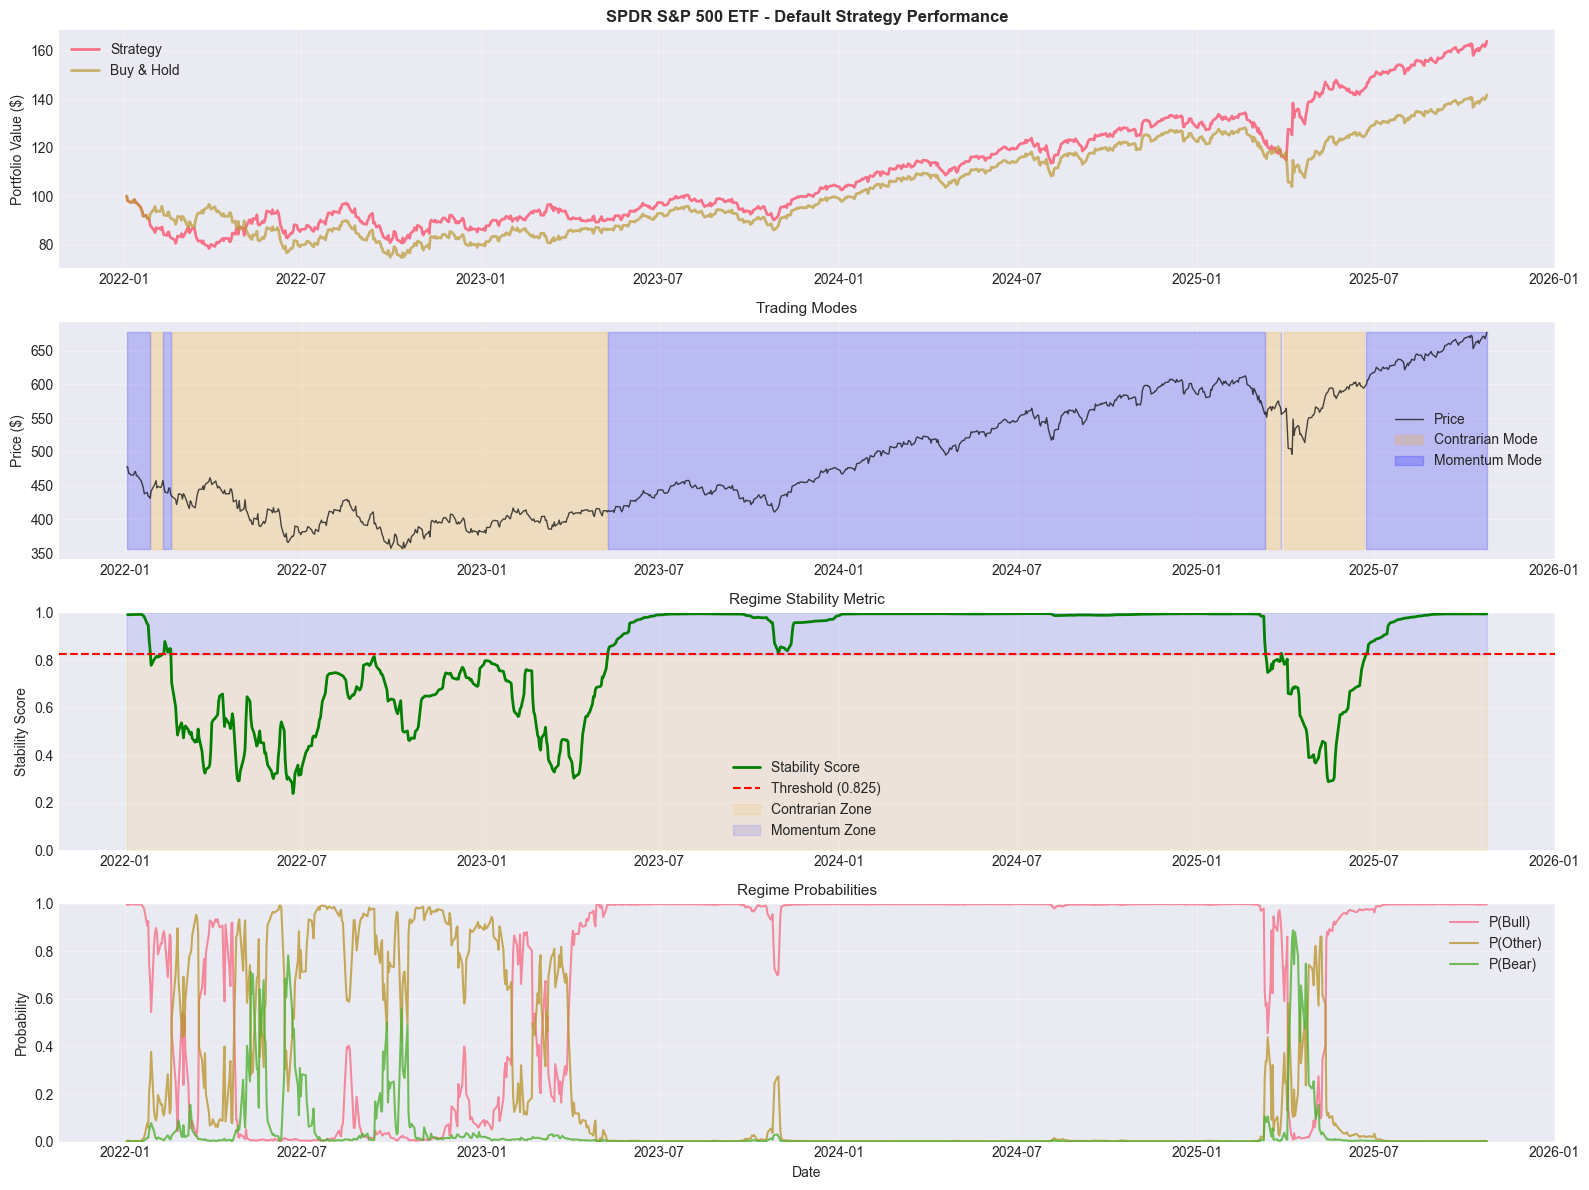

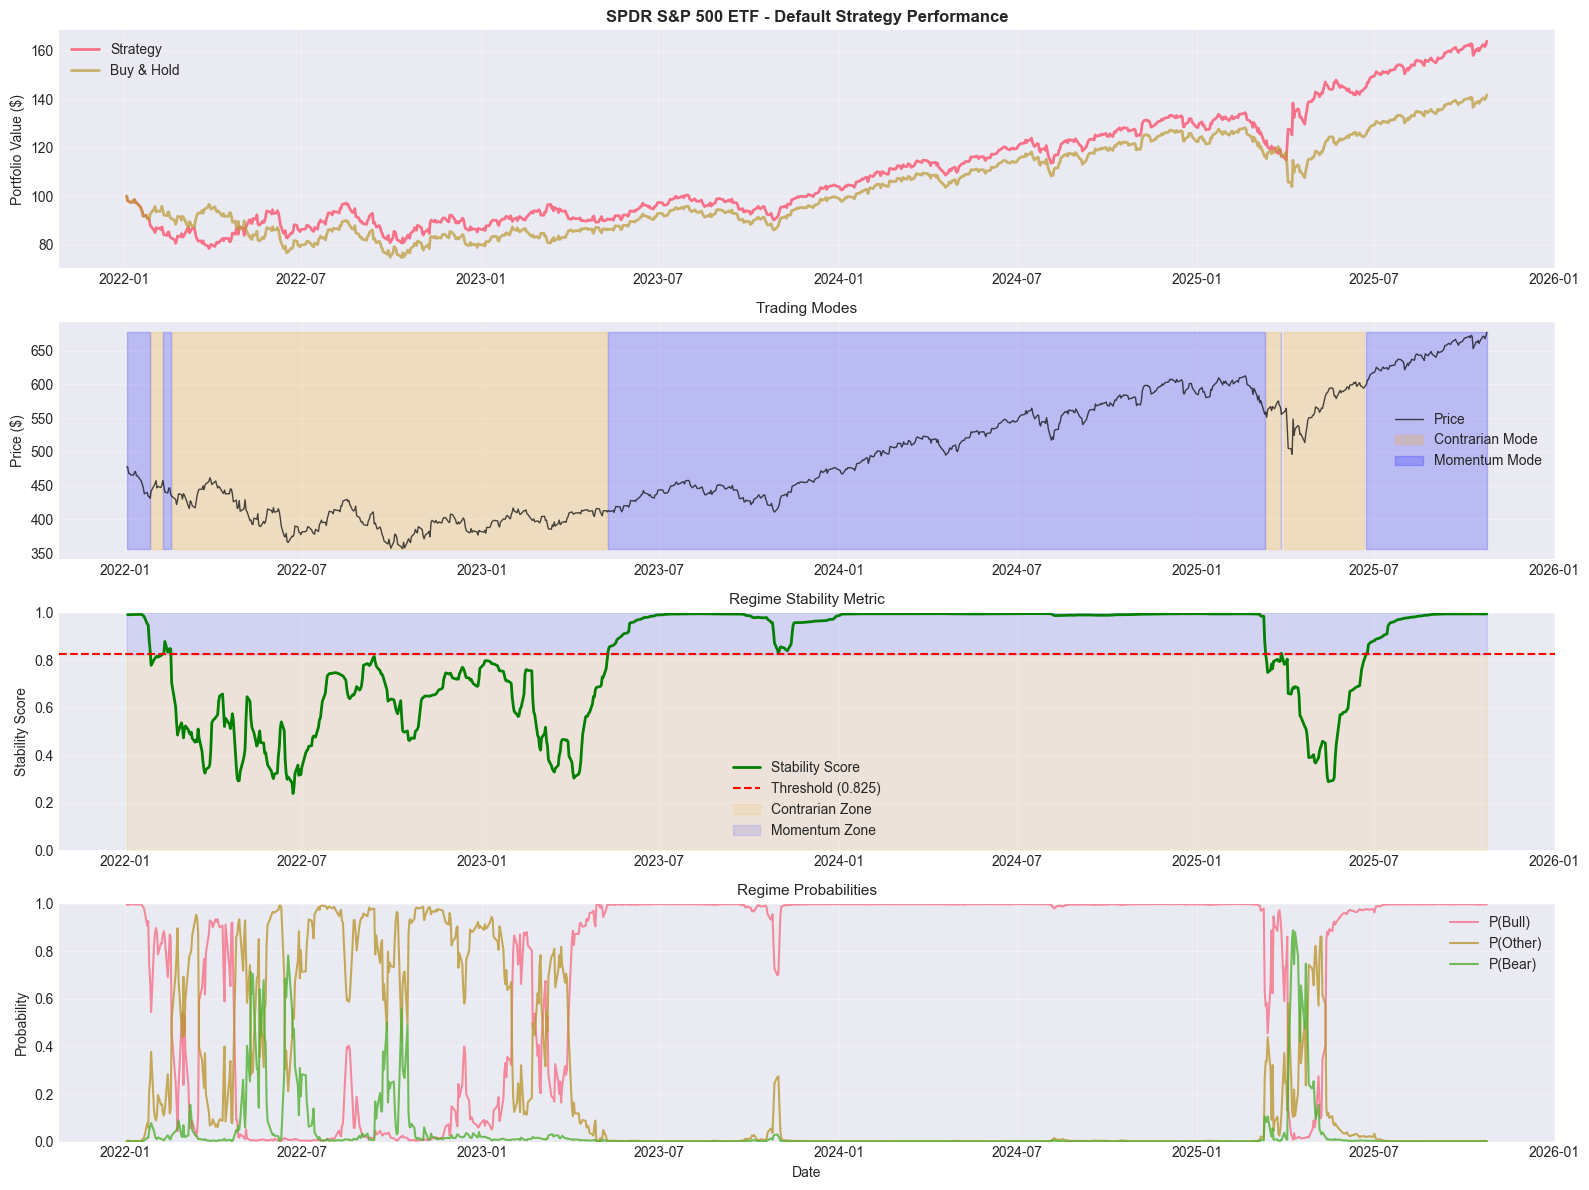

In [39]:
# Plot comprehensive performance visualization
strategy.plot_performance(f'{model.asset_name} - Default Strategy Performance')

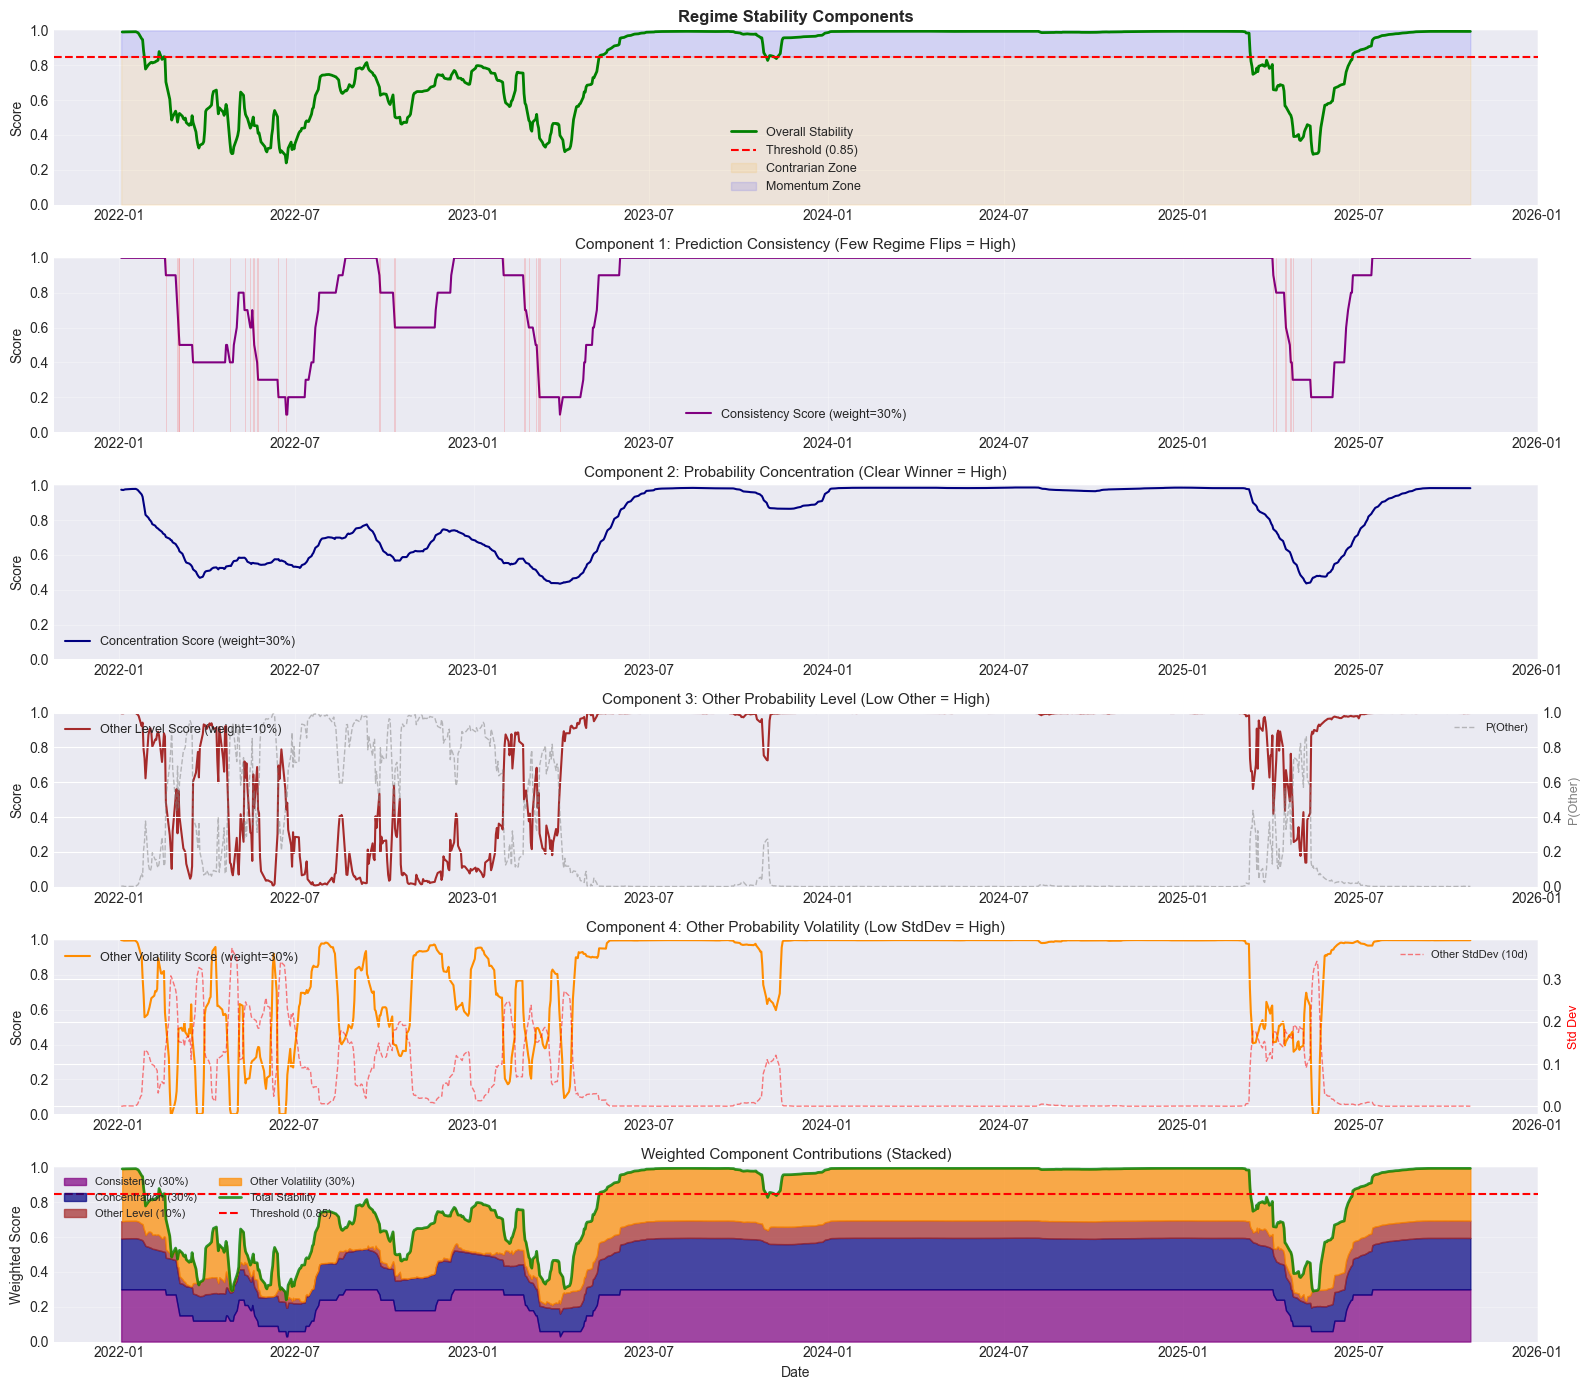

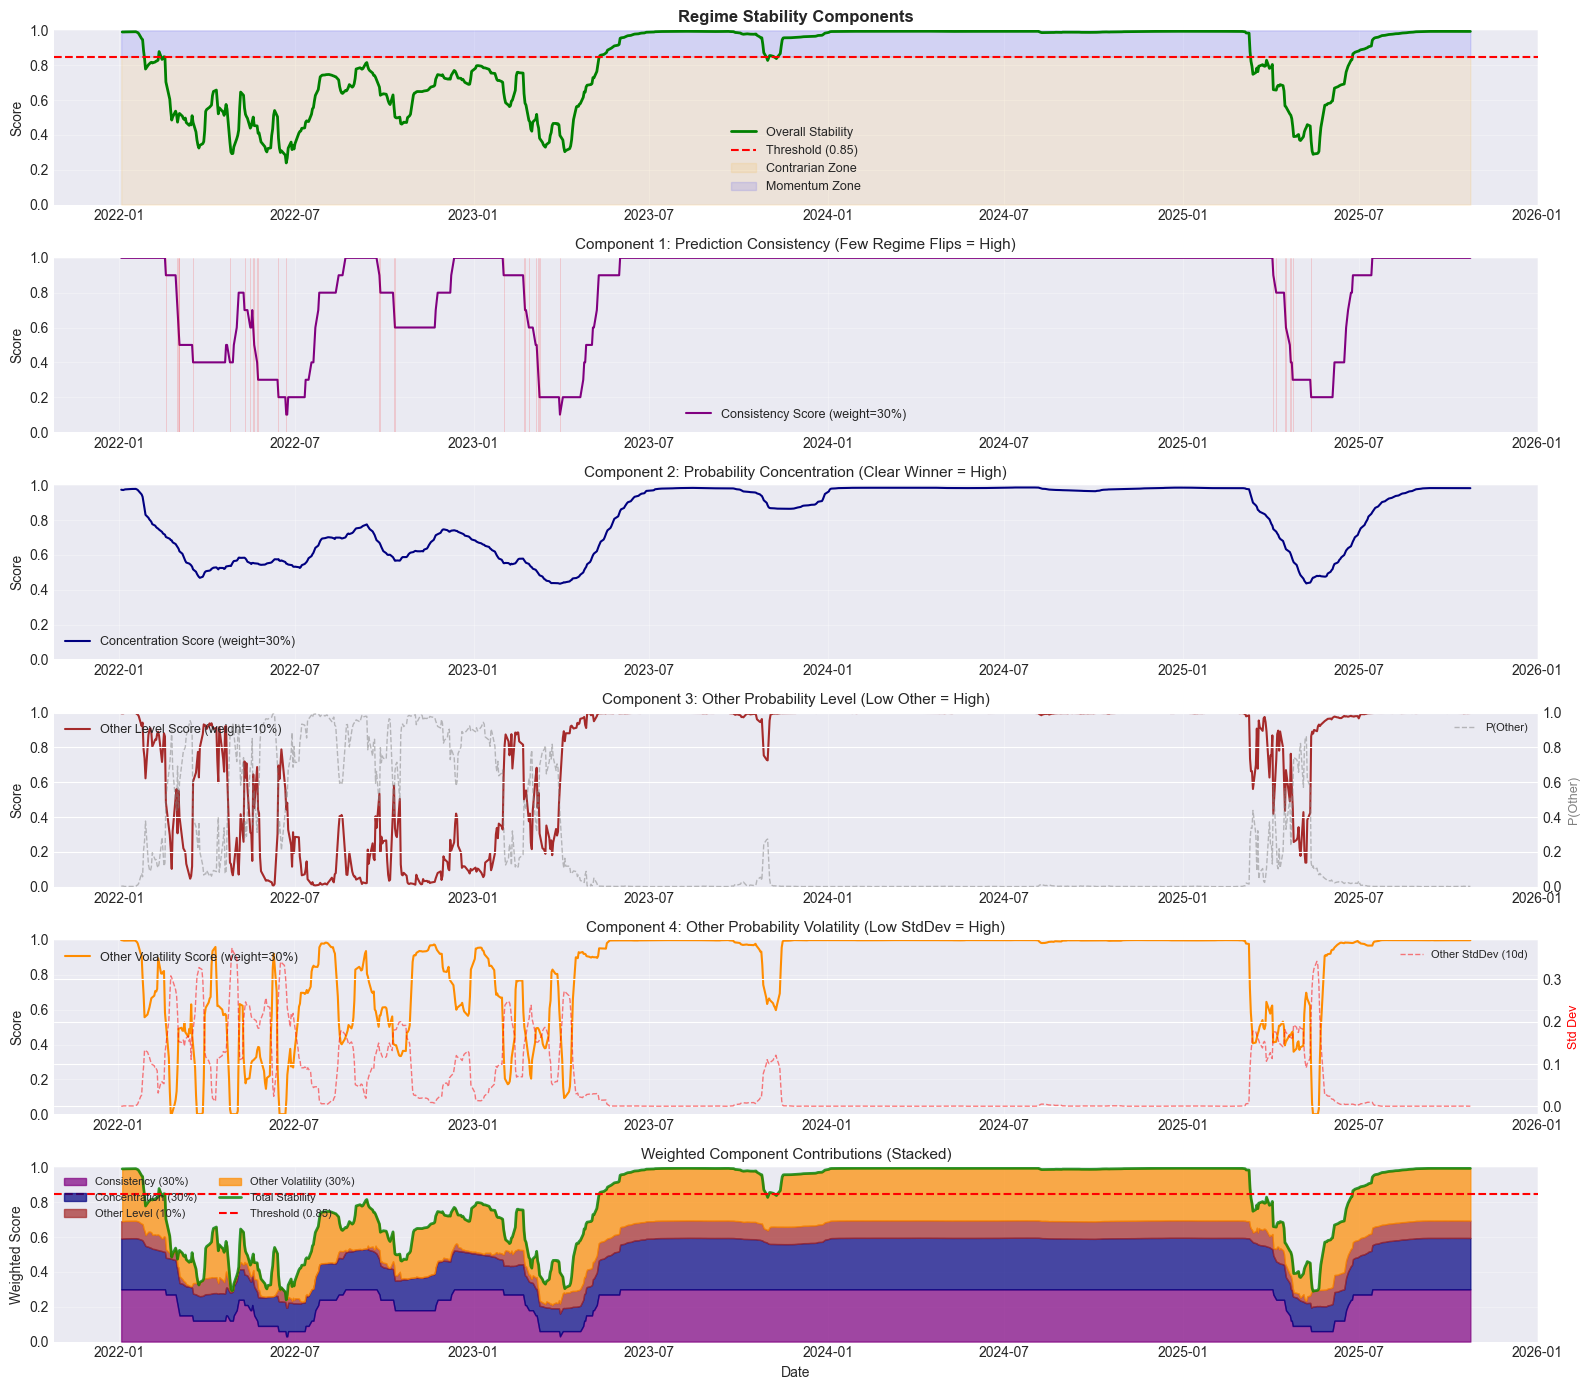

In [ ]:
strategy.plot_stability_components()